# Chapter 6 - RQ3 Local Image-Space Perturbations

## 1. Local Context and Source Notebooks

This skeleton is based on the local notebooks and scripts already in the repository:

- `vq-encoder-locality.ipynb`: first encoder-locality analysis using token-ID flip rates.
- `vq-encoder-locality-updated.ipynb`: improved encoder-locality analysis using cosine distance between codebook embeddings.
- `ch05_rq2_global_robustness.ipynb`: current chapter-notebook style for output folders, tables, figures, and chapter summaries.
- `LlamaGen/scripts/llamagen_robustness_experiment_dataset_export.py`: H1 patch-noise export schema for LlamaGen.
- `taming-transformers/scripts/vqgan_robustness_experiment_dataset_export.py`: H1 patch-noise export schema for VQGAN.

No cells in this notebook should write into the thesis repository. Outputs should stay next to the notebook under `chapter6_outputs/`.

## 2. Expected Run Layout

Each model run should come from the H1 experiment mode, `h1_patch_noise_encoder`. The expected run layout is:

- `metadata_part_*.jsonl`
- `images/{class_id}/{image_id}/0_original.png`
- `images/{class_id}/{image_id}/1_recon_clean.png`
- `images/{class_id}/{image_id}/2_input_patch_noise_low.png`
- `images/{class_id}/{image_id}/3_recon_patch_noise_low.png`
- `images/{class_id}/{image_id}/4_input_patch_noise_mid.png`
- `images/{class_id}/{image_id}/5_recon_patch_noise_mid.png`
- `images/{class_id}/{image_id}/6_input_patch_noise_high.png`
- `images/{class_id}/{image_id}/7_recon_patch_noise_high.png`
- optional: `8_input_patch_noise_xhigh.png`, `9_recon_patch_noise_xhigh.png`
- optional: `10_input_patch_masked.png`, `11_recon_patch_masked.png`
- optional but preferred: `codebook.npy`, shape `[K, D]`

The metadata records are expected to contain at least:

- `experiment_mode`
- `noise_std`
- `token_grid_hw`
- `patch_bbox_px`
- `patch_bbox_tok`
- `patch_side_tok`
- `indices_clean`
- `indices_low`, `indices_mid`, `indices_high`
- optional: `indices_xhigh`, `indices_masked`

## 3. Setup and Paths

The notebook reads the consolidated raw H1 encoder-locality exports from `/exp/data/h1_encoder_locality`. On the server this corresponds to `/home/nasiri/storage/jupyter/data/h1_encoder_locality`, where the raw VQGAN and LlamaGen runs are kept together.

Expected directories:

- `/exp/data/h1_encoder_locality/1767197584_robustness_dataset_vqgan_h1_patch_noise_encoder`
- `/exp/data/h1_encoder_locality/1780244076_robustness_dataset_llamagen_h1_patch_noise_encoder_patch8_seed0`

If either directory is missing, the inventory cell will fail directly with the missing path.


In [1]:
from __future__ import annotations

import json
import math
import os
import random
import shutil
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from IPython.display import display
from tqdm.auto import tqdm

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
})

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

MODEL_ORDER = ["vqgan", "llamagen"]
MODEL_LABELS = {"vqgan": "VQGAN", "llamagen": "LlamaGen"}
MODEL_COLORS = {"vqgan": "#B85C38", "llamagen": "#2F6F9F"}

@dataclass(frozen=True)
class ExperimentConfig:
    codebook_size: int = 16_384
    max_workers: int = min(32, os.cpu_count() or 8)
    torch_chunk_rows: int = 1024
    np_chunk_rows: int = 2048
    d_near: int = 2
    d_far: int = 6
    top_frac: float = 0.05

CFG = ExperimentConfig()

LEVELS = [
    ("low", "indices_low", "input_patch_noise_low", "recon_patch_noise_low"),
    ("mid", "indices_mid", "input_patch_noise_mid", "recon_patch_noise_mid"),
    ("high", "indices_high", "input_patch_noise_high", "recon_patch_noise_high"),
]
OPTIONAL_LEVELS = [
    ("xhigh", "indices_xhigh", "input_patch_noise_xhigh", "recon_patch_noise_xhigh"),
]
LEVEL_ORDER = [level for level, *_ in LEVELS]
LEVEL_TO_INDEX_KEY = {level: key for level, key, *_ in LEVELS + OPTIONAL_LEVELS}


def find_notebook_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "notebooks", cwd.parent / "notebooks"]
    for candidate in candidates:
        if candidate.name == "notebooks" or (candidate / "ch06_rq3_local_image_perturbations.ipynb").exists():
            return candidate
    return cwd


NOTEBOOK_DIR = find_notebook_root()
REPO_ROOT = NOTEBOOK_DIR.parent
RAW_DATA_ROOT = Path("/exp/data/h1_encoder_locality")

RUN_DIRS = {
    "vqgan": RAW_DATA_ROOT / "1767197584_robustness_dataset_vqgan_h1_patch_noise_encoder",
    "llamagen": RAW_DATA_ROOT / "1780244076_robustness_dataset_llamagen_h1_patch_noise_encoder_patch8_seed0",
}

OUTPUT_DIR = NOTEBOOK_DIR / "chapter6_outputs"
DATA_DIR = OUTPUT_DIR / "data"
FIGURE_DIR = OUTPUT_DIR / "figures"
SAMPLE_EXPORT_DIR = OUTPUT_DIR / "qualitative_samples"
CACHE_DIR = OUTPUT_DIR / "cache"

for directory in [DATA_DIR, FIGURE_DIR, SAMPLE_EXPORT_DIR, CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Notebook dir:", NOTEBOOK_DIR)
print("Raw data root:", RAW_DATA_ROOT)
for model, run_dir in RUN_DIRS.items():
    print(f"{MODEL_LABELS[model]} run dir:", run_dir if run_dir is not None else "<missing>")
print("Output dir:", OUTPUT_DIR)


Notebook dir: /exp/vq-explore/notebooks
Raw data root: /exp/data/h1_encoder_locality
VQGAN run dir: /exp/data/h1_encoder_locality/1767197584_robustness_dataset_vqgan_h1_patch_noise_encoder
LlamaGen run dir: /exp/data/h1_encoder_locality/1780244076_robustness_dataset_llamagen_h1_patch_noise_encoder_patch8_seed0
Output dir: /exp/vq-explore/notebooks/chapter6_outputs


## 4. Loading and Export Helpers

Helpers should stay small and boring:

- save tables to `chapter6_outputs/data/`
- save figures to `chapter6_outputs/figures/`
- save selected qualitative samples to `chapter6_outputs/qualitative_samples/`
- load JSONL metadata shards
- find sample image folders
- load and normalize `codebook.npy` when present
- build token patch masks from `patch_bbox_tok`

In [2]:
def save_table(df: pd.DataFrame, name: str) -> Path:
    path = DATA_DIR / name
    df.to_csv(path, index=False)
    print(f"saved: {path}")
    return path


def save_figure(fig: plt.Figure, name: str) -> Path:
    path = FIGURE_DIR / name
    fig.savefig(path, bbox_inches="tight")
    print(f"saved: {path}")
    return path


def save_json(data: dict, name: str) -> Path:
    path = DATA_DIR / name
    path.write_text(json.dumps(data, indent=2) + "\n")
    print(f"saved: {path}")
    return path


def save_df_cache(df: pd.DataFrame, path: Path) -> None:
    df.to_csv(path, index=False)
    print(f"cached: {path}")


def load_df_cache(path: Path) -> pd.DataFrame:
    return pd.read_csv(path)


def iter_jsonl(path: Path) -> Iterable[dict]:
    with path.open("r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if line:
                yield json.loads(line)


def find_metadata_files(run_dir: Path) -> list[Path]:
    files = sorted(run_dir.glob("metadata_part_*.jsonl"))
    if not files:
        raise FileNotFoundError(f"No metadata shards found under {run_dir}")
    return files


def peek_first_jsonl(path: Path) -> dict:
    for record in iter_jsonl(path):
        return record
    raise RuntimeError(f"Empty metadata file: {path}")


def load_metadata_df(run_dir: Path, max_records: int | None = None) -> pd.DataFrame:
    records = []
    for metadata_path in find_metadata_files(run_dir):
        for record in iter_jsonl(metadata_path):
            records.append(record)
            if max_records is not None and len(records) >= max_records:
                return pd.DataFrame(records)
    return pd.DataFrame(records)


def find_sample_dirs(images_root: Path, max_workers: int = CFG.max_workers) -> list[Path]:
    if not images_root.exists():
        raise FileNotFoundError(f"Missing images directory: {images_root}")
    class_dirs = sorted(path for path in images_root.iterdir() if path.is_dir())

    def scan_class_dir(class_dir: Path) -> list[Path]:
        return sorted(
            sample_dir
            for sample_dir in class_dir.iterdir()
            if sample_dir.is_dir() and (sample_dir / "0_original.png").exists()
        )

    sample_dirs: list[Path] = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(scan_class_dir, class_dir) for class_dir in class_dirs]
        iterator = tqdm(as_completed(futures), total=len(futures), desc=f"Scanning {images_root.name}", leave=False)
        for future in iterator:
            sample_dirs.extend(future.result())
    sample_dirs = sorted(sample_dirs)
    if not sample_dirs:
        raise RuntimeError(f"No samples found under {images_root}")
    return sample_dirs


def sample_id_from_record(record: dict) -> str:
    if "image_id" in record:
        return str(record["image_id"])
    original = record.get("original_path", "")
    return Path(original).stem if original else ""


def load_codebook(run_dir: Path) -> np.ndarray | None:
    path = run_dir / "codebook.npy"
    if not path.exists():
        return None
    codebook = np.load(path).astype(np.float32, copy=False)
    if codebook.ndim != 2:
        raise ValueError(f"Expected codebook [K, D], got {codebook.shape} at {path}")
    norms = np.linalg.norm(codebook, axis=1, keepdims=True)
    return codebook / np.clip(norms, 1e-12, None)


def bbox_area_tok(bbox: list[int] | tuple[int, int, int, int]) -> int:
    j0, i0, j1, i1 = map(int, bbox)
    return max(0, j1 - j0) * max(0, i1 - i0)


def build_inside_mask(records_df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray, tuple[int, int]]:
    h = records_df["token_grid_hw"].apply(lambda item: int(item[0])).to_numpy()
    w = records_df["token_grid_hw"].apply(lambda item: int(item[1])).to_numpy()
    hw = h * w
    if not np.all(hw == hw[0]):
        raise ValueError("token_grid_hw is not constant across records")

    h0, w0, hw0 = int(h[0]), int(w[0]), int(hw[0])
    inside_mask = np.zeros((len(records_df), hw0), dtype=bool)
    for row_index, bbox in enumerate(records_df["patch_bbox_tok"].to_list()):
        j0, i0, j1, i1 = map(int, bbox)
        mask_2d = inside_mask[row_index].reshape(h0, w0)
        mask_2d[i0:i1, j0:j1] = True

    inside_count = inside_mask.sum(axis=1).astype(np.float32)
    outside_count = (hw0 - inside_count).astype(np.float32)
    return inside_mask, inside_count, outside_count, (h0, w0)


def build_distance_map(records_df: pd.DataFrame, grid_hw: tuple[int, int]) -> np.ndarray:
    h0, w0 = grid_hw
    ii, jj = np.meshgrid(np.arange(h0), np.arange(w0), indexing="ij")
    dist_map = np.zeros((len(records_df), h0 * w0), dtype=np.int16)
    for row_index, bbox in enumerate(records_df["patch_bbox_tok"].to_list()):
        j0, i0, j1, i1 = map(int, bbox)
        di = np.where(ii < i0, i0 - ii, np.where(ii > (i1 - 1), ii - (i1 - 1), 0))
        dj = np.where(jj < j0, j0 - jj, np.where(jj > (j1 - 1), jj - (j1 - 1), 0))
        dist_map[row_index] = (di + dj).astype(np.int16).reshape(-1)
    return dist_map


def find_full_image_set(sample_dir: Path) -> dict[int, Path]:
    out = {}
    for index in range(12):
        matches = sorted(sample_dir.glob(f"{index}_*.png"))
        if matches:
            out[index] = matches[0]
    return out


def copy_sample_dir(sample_dir: Path, model: str) -> Path:
    target = SAMPLE_EXPORT_DIR / model / sample_dir.name
    if target.exists():
        shutil.rmtree(target)
    shutil.copytree(sample_dir, target)
    return target


def summarize_array(values: np.ndarray) -> dict[str, float]:
    values = np.asarray(values, dtype=np.float64)
    return {
        "mean": float(np.nanmean(values)),
        "std": float(np.nanstd(values)),
        "median": float(np.nanmedian(values)),
        "q90": float(np.nanquantile(values, 0.90)),
        "q99": float(np.nanquantile(values, 0.99)),
    }


def cache_path(name: str) -> Path:
    return CACHE_DIR / name


## 5. Inventory and Validation

This section should verify only the facts needed before analysis:

- number of images / metadata records per model
- number of metadata shards
- available noise levels from `noise_std`
- token grid size, expected to be `16 x 16`
- patch size in token space, expected to be an `8 x 8` square for the standard run
- whether `codebook.npy` is available for embedding-distance metrics
- whether x-high and black-mask variants exist

Planned output: `ch06_table_run_inventory.csv`.

In [3]:
def load_run_inventory(model: str, run_dir: Path | None) -> tuple[str, dict]:
    if run_dir is None:
        raise FileNotFoundError(f"No H1 encoder-locality run configured for {MODEL_LABELS[model]}")
    if not run_dir.exists():
        raise FileNotFoundError(f"Missing run directory for {model}: {run_dir}")

    images_root = run_dir / "images"
    metadata_files = find_metadata_files(run_dir)
    first_record = peek_first_jsonl(metadata_files[0])
    sample_dirs = find_sample_dirs(images_root)
    codebook = load_codebook(run_dir)

    return model, {
        "run_dir": run_dir,
        "images_root": images_root,
        "metadata_files": metadata_files,
        "first_record": first_record,
        "sample_dirs": sample_dirs,
        "codebook": codebook,
    }


runs = {}
items = [(model, RUN_DIRS[model]) for model in MODEL_ORDER]
progress = tqdm(total=len(items), desc="Loading RQ3 run inventory")

with ThreadPoolExecutor(max_workers=min(len(items), CFG.max_workers)) as executor:
    futures = {executor.submit(load_run_inventory, model, run_dir): model for model, run_dir in items}
    for future in as_completed(futures):
        model, run = future.result()
        runs[model] = run
        progress.update(1)

progress.close()

runs = {model: runs[model] for model in MODEL_ORDER}

inventory_rows = []
for model, run in runs.items():
    first = run["first_record"]
    noise_std = first.get("noise_std", [])
    codebook = run["codebook"]
    inventory_rows.append({
        "model": MODEL_LABELS[model],
        "run_dir": str(run["run_dir"]),
        "n_samples": len(run["sample_dirs"]),
        "n_metadata_shards": len(run["metadata_files"]),
        "experiment_mode": first.get("experiment_mode"),
        "noise_std": json.dumps(noise_std),
        "token_grid_hw": json.dumps(first.get("token_grid_hw")),
        "patch_side_tok": first.get("patch_side_tok"),
        "has_xhigh": "indices_xhigh" in first,
        "has_masked": "indices_masked" in first,
        "has_codebook": codebook is not None,
        "codebook_shape": json.dumps(list(codebook.shape)) if codebook is not None else "",
        "metadata_keys": ", ".join(sorted(first.keys())),
    })

inventory_df = pd.DataFrame(inventory_rows)
save_table(inventory_df, "ch06_table_run_inventory.csv")
display(inventory_df)


Loading RQ3 run inventory:   0%|          | 0/2 [00:00<?, ?it/s]

Scanning images:   0%|          | 0/1000 [00:00<?, ?it/s]

Scanning images:   0%|          | 0/1000 [00:00<?, ?it/s]

saved: /exp/vq-explore/notebooks/chapter6_outputs/data/ch06_table_run_inventory.csv


,model,run_dir,n_samples,n_metadata_shards,experiment_mode,noise_std,token_grid_hw,patch_side_tok,has_xhigh,has_masked,has_codebook,codebook_shape,metadata_keys
0,VQGAN,/exp/data/h1_encoder_locality/1767197584_robus...,50000,8,h1_patch_noise_encoder,"[0.1, 0.25, 0.5, 1.0]","[16, 16]",8,True,True,False,,"experiment_mode, has_masked_occlusion, image_i..."
1,LlamaGen,/exp/data/h1_encoder_locality/1780244076_robus...,50000,16,h1_patch_noise_encoder,"[0.1, 0.25, 0.5, 1.0]","[16, 16]",8,True,True,False,,"experiment_mode, has_masked_occlusion, image_i..."


## 6. Qualitative Patch-Noise Samples

Select a small set of examples that are useful for the thesis figure. The intended panel is:

- row 1: original, low-noise input, mid-noise input, high-noise input
- row 2: clean reconstruction, low-noise reconstruction, mid-noise reconstruction, high-noise reconstruction
- row 3: token response heatmaps for low, mid, and high perturbations

The pixel patch should be drawn on image rows. The token patch should be drawn on heatmaps.

Planned outputs:

- `ch06_fig_patch_noise_qualitative_vqgan.png`
- `ch06_fig_patch_noise_qualitative_llamagen.png`
- copied sample folders under `chapter6_outputs/qualitative_samples/`

VQGAN records: 50000 columns: 19
LlamaGen records: 50000 columns: 19
Selected VQGAN qualitative IDs: ['n01440764/ILSVRC2012_val_00000293', 'n01440764/ILSVRC2012_val_00009396', 'n01440764/ILSVRC2012_val_00017700']
Selected LlamaGen qualitative IDs: ['n01440764/ILSVRC2012_val_00000293', 'n01440764/ILSVRC2012_val_00028158', 'n01440764/ILSVRC2012_val_00039905']
saved: /exp/vq-explore/notebooks/chapter6_outputs/figures/ch06_fig_patch_noise_qualitative_vqgan.png


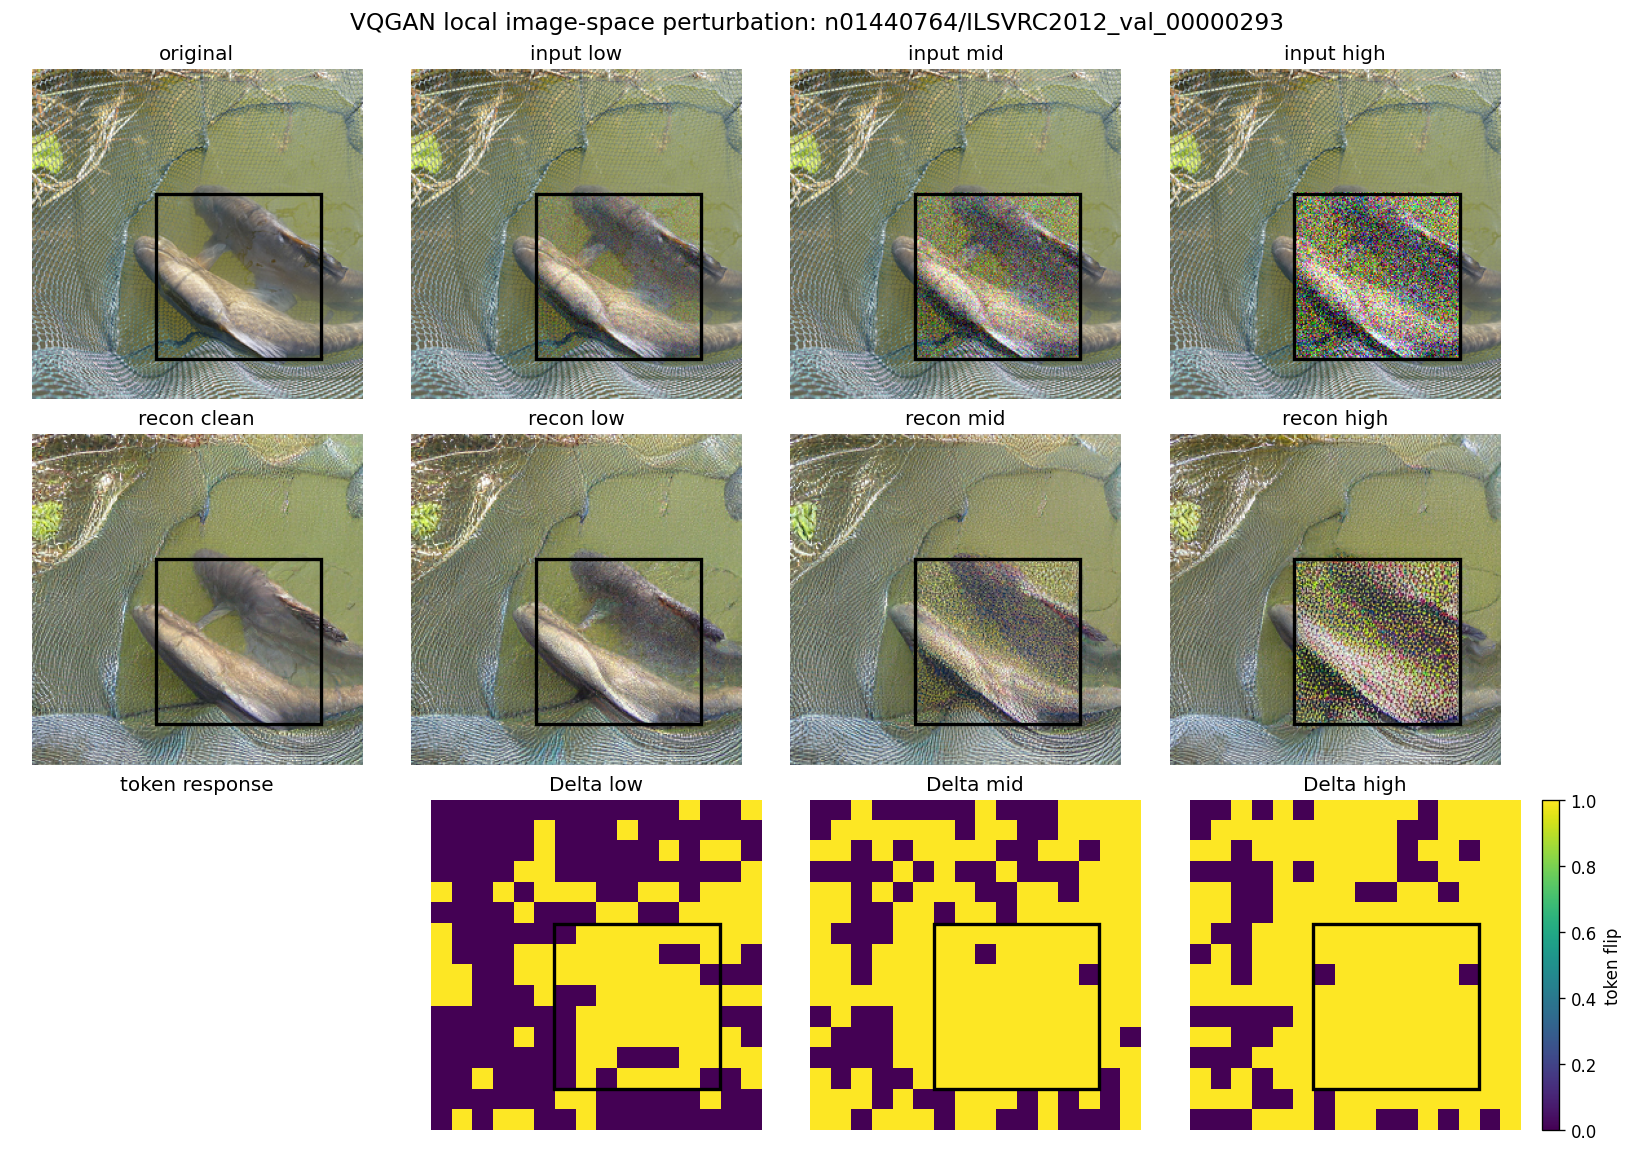

saved: /exp/vq-explore/notebooks/chapter6_outputs/figures/ch06_fig_patch_noise_qualitative_llamagen.png


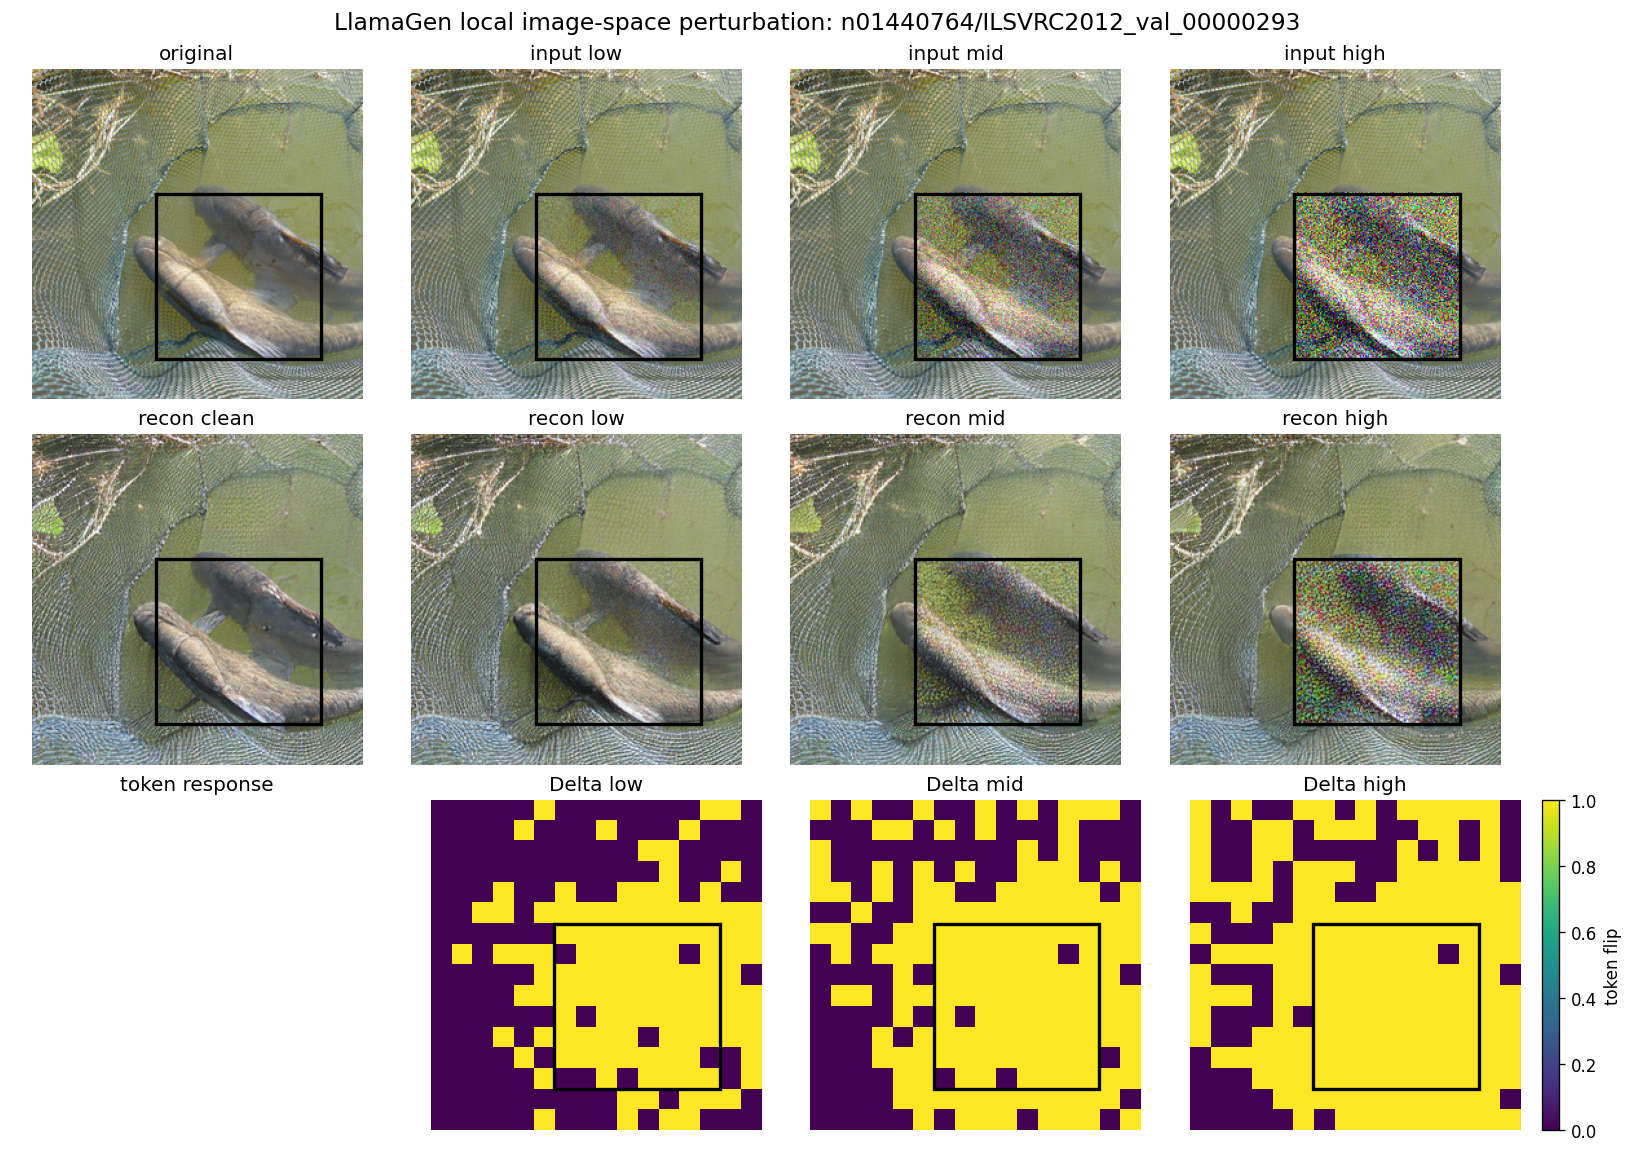

In [4]:
def load_model_records(model: str, max_records: int | None = None) -> pd.DataFrame:
    df = load_metadata_df(runs[model]["run_dir"], max_records=max_records)
    df["image_id"] = df.apply(lambda row: sample_id_from_record(row.to_dict()), axis=1)
    df["model"] = model
    return df


records_by_model = {model: load_model_records(model) for model in MODEL_ORDER}

for model, df_model in records_by_model.items():
    print(MODEL_LABELS[model], "records:", len(df_model), "columns:", len(df_model.columns))
    required = ["indices_clean", "indices_low", "indices_mid", "indices_high", "patch_bbox_px", "patch_bbox_tok", "token_grid_hw", "noise_std"]
    missing = [key for key in required if key not in df_model.columns]
    if missing:
        raise KeyError(f"{MODEL_LABELS[model]} missing required metadata fields: {missing}")


def sample_dir_by_image_id(model: str) -> dict[str, Path]:
    return {f"{sample_dir.parent.name}/{sample_dir.name}": sample_dir for sample_dir in runs[model]["sample_dirs"]}


sample_dirs_by_model = {model: sample_dir_by_image_id(model) for model in MODEL_ORDER}

selected_ids_by_model = {
    model: records_by_model[model]["image_id"].head(3).tolist()
    for model in MODEL_ORDER
}
for model, image_ids in selected_ids_by_model.items():
    print(f"Selected {MODEL_LABELS[model]} qualitative IDs:", image_ids)


def token_delta_grid(row: pd.Series, level: str, codebook_unit: np.ndarray | None) -> np.ndarray:
    h, w = map(int, row["token_grid_hw"])
    clean = np.asarray(row["indices_clean"], dtype=np.int64).reshape(h, w)
    noisy = np.asarray(row[LEVEL_TO_INDEX_KEY[level]], dtype=np.int64).reshape(h, w)
    if codebook_unit is None:
        return (clean != noisy).astype(np.float32)
    ec = codebook_unit[clean]
    en = codebook_unit[noisy]
    cos = np.clip((ec * en).sum(axis=-1), -1.0, 1.0)
    return ((1.0 - cos) * 0.5).astype(np.float32)


def draw_px_bbox(ax, bbox_px, color="black", linewidth=2):
    x0, y0, x1, y1 = map(int, bbox_px)
    rect = plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, color=color, linewidth=linewidth)
    ax.add_patch(rect)


def draw_tok_bbox(ax, bbox_tok, color="black", linewidth=2):
    j0, i0, j1, i1 = map(int, bbox_tok)
    rect = plt.Rectangle((j0 - 0.5, i0 - 0.5), j1 - j0, i1 - i0, fill=False, color=color, linewidth=linewidth)
    ax.add_patch(rect)


def make_qualitative_panel(model: str, image_id: str) -> plt.Figure:
    df_model = records_by_model[model]
    row = df_model[df_model["image_id"] == image_id].iloc[0]
    sample_dir = sample_dirs_by_model[model][image_id]
    files = find_full_image_set(sample_dir)
    codebook = runs[model]["codebook"]

    fig, axes = plt.subplots(3, 4, figsize=(13.5, 9.5), constrained_layout=True)
    fig.suptitle(f"{MODEL_LABELS[model]} local image-space perturbation: {image_id}", fontsize=14)

    top_indices = [0, 2, 4, 6]
    mid_indices = [1, 3, 5, 7]
    top_titles = ["original", "input low", "input mid", "input high"]
    mid_titles = ["recon clean", "recon low", "recon mid", "recon high"]

    for col, (file_index, title) in enumerate(zip(top_indices, top_titles)):
        ax = axes[0, col]
        with Image.open(files[file_index]) as im:
            ax.imshow(im.convert("RGB"))
        draw_px_bbox(ax, row["patch_bbox_px"])
        ax.set_title(title)
        ax.axis("off")

    for col, (file_index, title) in enumerate(zip(mid_indices, mid_titles)):
        ax = axes[1, col]
        with Image.open(files[file_index]) as im:
            ax.imshow(im.convert("RGB"))
        draw_px_bbox(ax, row["patch_bbox_px"])
        ax.set_title(title)
        ax.axis("off")

    axes[2, 0].axis("off")
    axes[2, 0].set_title("token response")
    last_im = None
    for col, level in enumerate(["low", "mid", "high"], start=1):
        ax = axes[2, col]
        delta = token_delta_grid(row, level, codebook)
        last_im = ax.imshow(delta, vmin=0, vmax=1)
        draw_tok_bbox(ax, row["patch_bbox_tok"])
        ax.set_title(f"Delta {level}")
        ax.axis("off")
    if last_im is not None:
        fig.colorbar(last_im, ax=axes[2, 1:], fraction=0.035, pad=0.02, label="embedding distance" if codebook is not None else "token flip")
    return fig


for model in MODEL_ORDER:
    image_id = selected_ids_by_model[model][0]
    fig = make_qualitative_panel(model, image_id)
    save_figure(fig, f"ch06_fig_patch_noise_qualitative_{model}.png")
    plt.show()
    copy_sample_dir(sample_dirs_by_model[model][image_id], model)


## 7. Metric Definitions

Let `z_0` be the clean token grid and `z_sigma` the token grid after applying patch-local pixel noise. Let `P` be the token-space patch induced by the pixel patch.

Primary discrete metric:

$$\mathrm{flip}_\sigma(i,j)=\mathbf{1}[z_\sigma(i,j)\ne z_0(i,j)].$$

Primary embedding-distance metric when `codebook.npy` is available:

$$\Delta_\sigma(i,j)=\frac{1-\langle \hat E[z_0(i,j)],\hat E[z_\sigma(i,j)]\rangle}{2}.$$

Inside and outside responses:

$$\mathrm{inside}_\sigma=\frac{1}{|P|}\sum_{(i,j)\in P}\Delta_\sigma(i,j),\qquad
\mathrm{outside}_\sigma=\frac{1}{|P^c|}\sum_{(i,j)\in P^c}\Delta_\sigma(i,j).$$

Leakage ratio:

$$\mathrm{leakage\ ratio}_\sigma=\frac{\mathrm{outside}_\sigma}{\mathrm{inside}_\sigma+\epsilon}.$$

Distance-to-patch response:

$$p_\sigma(d)=\mathbb{E}[\Delta_\sigma(i,j)\mid \mathrm{dist}((i,j),P)=d].$$

## 8. Inside / Outside Encoder Response

Compute per-image inside response, outside response, and leakage ratio for each model and noise level. Use embedding distance as the primary metric when codebooks are available; also keep token-ID flip rates as an interpretable secondary metric.

Planned outputs:

- `ch06_encoder_locality_rows.csv`
- `ch06_table_inside_outside_summary.csv`
- `ch06_fig_inside_outside_response.png`
- `ch06_fig_leakage_ratio_vs_sigma.png`

Inside/outside VQGAN low:   0%|          | 0/49 [00:00<?, ?it/s]

Inside/outside VQGAN mid:   0%|          | 0/49 [00:00<?, ?it/s]

Inside/outside VQGAN high:   0%|          | 0/49 [00:00<?, ?it/s]

cached: /exp/vq-explore/notebooks/chapter6_outputs/cache/ch06_encoder_locality_rows_vqgan.csv


Inside/outside LlamaGen low:   0%|          | 0/49 [00:00<?, ?it/s]

Inside/outside LlamaGen mid:   0%|          | 0/49 [00:00<?, ?it/s]

Inside/outside LlamaGen high:   0%|          | 0/49 [00:00<?, ?it/s]

cached: /exp/vq-explore/notebooks/chapter6_outputs/cache/ch06_encoder_locality_rows_llamagen.csv
saved: /exp/vq-explore/notebooks/chapter6_outputs/data/ch06_encoder_locality_rows.csv
saved: /exp/vq-explore/notebooks/chapter6_outputs/data/ch06_table_inside_outside_summary.csv


,model,level,sigma,inside_response_mean,inside_response_std,inside_response_median,inside_response_q90,inside_response_q99,outside_response_mean,outside_response_std,...,flip_outside_mean,flip_outside_std,flip_outside_median,flip_outside_q90,flip_outside_q99,flip_leakage_ratio_mean,flip_leakage_ratio_std,flip_leakage_ratio_median,flip_leakage_ratio_q90,flip_leakage_ratio_q99
0,VQGAN,low,0.10,0.787605,0.129160,0.81250,0.937500,0.984375,0.299093,0.098267,...,0.299093,0.098267,0.291667,0.432292,0.541667,0.374813,0.090445,0.371429,0.494048,0.600000
1,VQGAN,mid,0.25,0.952039,0.044514,0.96875,1.000000,1.000000,0.441234,0.084613,...,0.441234,0.084613,0.437500,0.552083,0.645833,0.462345,0.080540,0.459068,0.567708,0.656250
2,VQGAN,high,0.50,0.987679,0.016555,1.00000,1.000000,1.000000,0.520889,0.079462,...,0.520889,0.079462,0.520833,0.625000,0.708333,0.527170,0.078595,0.524590,0.630208,0.714286
3,LlamaGen,low,0.10,0.821673,0.121444,0.84375,0.953125,1.000000,0.301759,0.101319,...,0.301759,0.101319,0.296875,0.437500,0.552083,0.361298,0.091575,0.356725,0.481481,0.597888
4,LlamaGen,mid,0.25,0.960462,0.042380,0.96875,1.000000,1.000000,0.427771,0.082862,...,0.427771,0.082862,0.427083,0.536458,0.630208,0.444214,0.078448,0.442529,0.546448,0.640212
5,LlamaGen,high,0.50,0.990918,0.014791,1.00000,1.000000,1.000000,0.504776,0.077052,...,0.504776,0.077052,0.500000,0.604167,0.692708,0.509183,0.076038,0.505208,0.609375,0.697917


saved: /exp/vq-explore/notebooks/chapter6_outputs/figures/ch06_fig_inside_outside_response.png
saved: /exp/vq-explore/notebooks/chapter6_outputs/figures/ch06_fig_leakage_ratio_vs_sigma.png


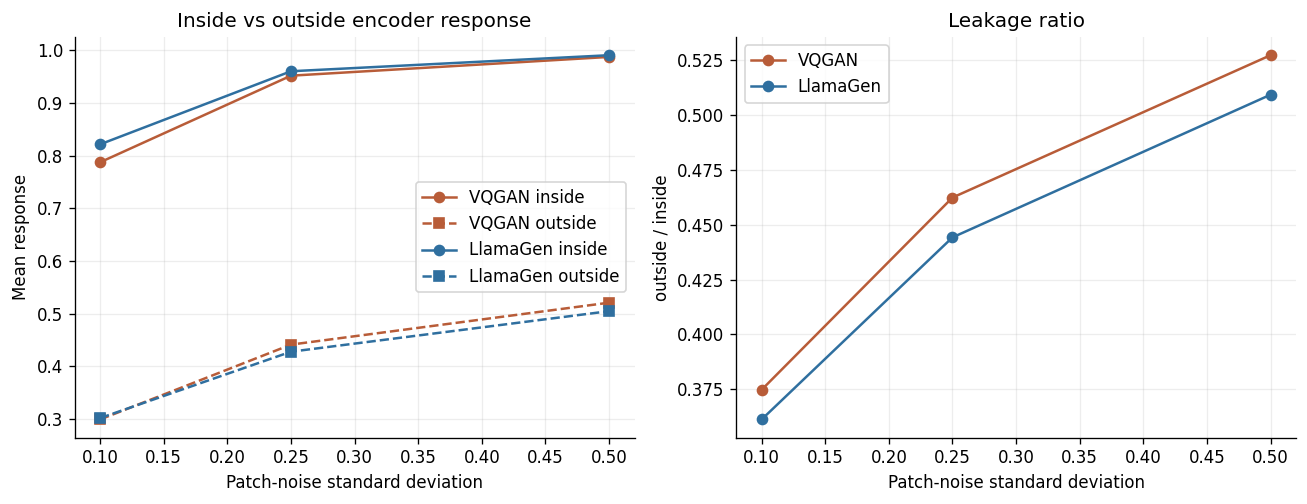

In [5]:
_TORCH_CODEBOOK_CACHE = {}


def get_torch_codebook(codebook_unit: np.ndarray):
    key = id(codebook_unit)
    if key not in _TORCH_CODEBOOK_CACHE:
        device = torch.device("cuda")
        _TORCH_CODEBOOK_CACHE[key] = torch.from_numpy(codebook_unit).to(device=device, dtype=torch.float32)
    return _TORCH_CODEBOOK_CACHE[key]


def compute_delta_chunk(clean_ids: np.ndarray, noisy_ids: np.ndarray, codebook_unit: np.ndarray | None) -> np.ndarray:
    if codebook_unit is None:
        return (clean_ids != noisy_ids).astype(np.float32)
    if torch.cuda.is_available():
        device = torch.device("cuda")
        codebook_t = get_torch_codebook(codebook_unit)
        clean_t = torch.from_numpy(clean_ids).to(device=device, dtype=torch.long)
        noisy_t = torch.from_numpy(noisy_ids).to(device=device, dtype=torch.long)
        with torch.no_grad():
            ec = codebook_t[clean_t]
            en = codebook_t[noisy_t]
            cos = (ec * en).sum(dim=-1).clamp(-1.0, 1.0)
            delta = ((1.0 - cos) * 0.5).float().cpu().numpy()
        return delta.astype(np.float32, copy=False)
    ec = codebook_unit[clean_ids]
    en = codebook_unit[noisy_ids]
    cos = np.clip((ec * en).sum(axis=-1), -1.0, 1.0)
    return ((1.0 - cos) * 0.5).astype(np.float32)


def compute_inside_outside_for_model(model: str, force: bool = False) -> pd.DataFrame:
    path = cache_path(f"ch06_encoder_locality_rows_{model}.csv")
    if not force and path.exists():
        print(f"loading cached encoder-locality rows for {model}")
        return load_df_cache(path)

    df_model = records_by_model[model]
    codebook = runs[model]["codebook"]
    inside_mask, inside_count, outside_count, grid_hw = build_inside_mask(df_model)
    clean_ids = np.asarray(df_model["indices_clean"].to_list(), dtype=np.int32)

    rows = []
    iterator = LEVELS
    for level, index_key, _, _ in iterator:
        noisy_ids = np.asarray(df_model[index_key].to_list(), dtype=np.int32)
        inside_values = np.empty(len(df_model), dtype=np.float32)
        outside_values = np.empty(len(df_model), dtype=np.float32)
        flip_inside_values = np.empty(len(df_model), dtype=np.float32)
        flip_outside_values = np.empty(len(df_model), dtype=np.float32)

        chunk_iter = tqdm(range(0, len(df_model), CFG.torch_chunk_rows), desc=f"Inside/outside {MODEL_LABELS[model]} {level}")
        for start in chunk_iter:
            end = min(start + CFG.torch_chunk_rows, len(df_model))
            delta = compute_delta_chunk(clean_ids[start:end], noisy_ids[start:end], codebook)
            mask = inside_mask[start:end]
            outside_mask = ~mask
            inside_values[start:end] = (delta * mask).sum(axis=1) / inside_count[start:end]
            outside_values[start:end] = (delta * outside_mask).sum(axis=1) / outside_count[start:end]

            flips = (clean_ids[start:end] != noisy_ids[start:end])
            flip_inside_values[start:end] = (flips * mask).sum(axis=1) / inside_count[start:end]
            flip_outside_values[start:end] = (flips * outside_mask).sum(axis=1) / outside_count[start:end]

        sigma = float(df_model["noise_std"].iloc[0][LEVEL_ORDER.index(level)])
        for idx, image_id in enumerate(df_model["image_id"].to_numpy()):
            inside = float(inside_values[idx])
            outside = float(outside_values[idx])
            flip_inside = float(flip_inside_values[idx])
            flip_outside = float(flip_outside_values[idx])
            rows.append({
                "model": model,
                "image_id": image_id,
                "level": level,
                "sigma": sigma,
                "metric": "embedding_distance" if codebook is not None else "token_flip",
                "inside_response": inside,
                "outside_response": outside,
                "leakage_ratio": outside / (inside + 1e-8),
                "flip_inside": flip_inside,
                "flip_outside": flip_outside,
                "flip_leakage_ratio": flip_outside / (flip_inside + 1e-8),
                "patch_area_tokens": int(inside_count[idx]),
                "total_tokens": int(grid_hw[0] * grid_hw[1]),
            })

    out_df = pd.DataFrame(rows)
    save_df_cache(out_df, path)
    return out_df


locality_df = pd.concat(
    [compute_inside_outside_for_model(model, force=False) for model in MODEL_ORDER],
    ignore_index=True,
)
save_table(locality_df, "ch06_encoder_locality_rows.csv")

summary_rows = []
for (model, level), group in locality_df.groupby(["model", "level"], sort=False):
    row = {"model": MODEL_LABELS[model], "level": level, "sigma": float(group["sigma"].iloc[0])}
    for col in ["inside_response", "outside_response", "leakage_ratio", "flip_inside", "flip_outside", "flip_leakage_ratio"]:
        stats = summarize_array(group[col].to_numpy())
        for key, value in stats.items():
            row[f"{col}_{key}"] = value
    summary_rows.append(row)

inside_outside_summary = pd.DataFrame(summary_rows)
save_table(inside_outside_summary, "ch06_table_inside_outside_summary.csv")
display(inside_outside_summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharex=True)
for model in MODEL_ORDER:
    label = MODEL_LABELS[model]
    color = MODEL_COLORS[model]
    sub = inside_outside_summary[inside_outside_summary["model"] == label].sort_values("sigma")
    axes[0].plot(sub["sigma"], sub["inside_response_mean"], marker="o", color=color, label=f"{label} inside")
    axes[0].plot(sub["sigma"], sub["outside_response_mean"], marker="s", linestyle="--", color=color, label=f"{label} outside")
    axes[1].plot(sub["sigma"], sub["leakage_ratio_mean"], marker="o", color=color, label=label)

axes[0].set_title("Inside vs outside encoder response")
axes[0].set_xlabel("Patch-noise standard deviation")
axes[0].set_ylabel("Mean response")
axes[0].legend()
axes[1].set_title("Leakage ratio")
axes[1].set_xlabel("Patch-noise standard deviation")
axes[1].set_ylabel("outside / inside")
axes[1].legend()
fig.tight_layout()
save_figure(fig, "ch06_fig_inside_outside_response.png")
save_figure(fig, "ch06_fig_leakage_ratio_vs_sigma.png")
plt.show()


## 9. Distance-to-Patch Leakage Profile

A scalar outside response cannot distinguish boundary spillover from far-field response. This section should compute the Manhattan distance from every token position to the patch and estimate `p_sigma(d)` for each model and noise level.

Planned outputs:

- `ch06_table_distance_profile.csv`
- `ch06_fig_distance_profile_embedding.png`
- `ch06_fig_distance_profile_flip.png`
- optional: `ch06_fig_distance_profile_embedding_log.png`

loading cached distance profile for vqgan
loading cached distance profile for llamagen
saved: /exp/vq-explore/notebooks/chapter6_outputs/data/ch06_table_distance_profile.csv


,model,level,sigma,distance,count_tokens_total,mean_embedding_distance,flip_probability
0,vqgan,low,0.1,0,3200000,0.787605,0.787605
1,vqgan,low,0.1,1,1422912,0.597390,0.597390
2,vqgan,low,0.1,2,1404408,0.420480,0.420480
3,vqgan,low,0.1,3,1345483,0.294815,0.294815
4,vqgan,low,0.1,4,1247461,0.226010,0.226010


saved: /exp/vq-explore/notebooks/chapter6_outputs/figures/ch06_fig_distance_profile_embedding.png


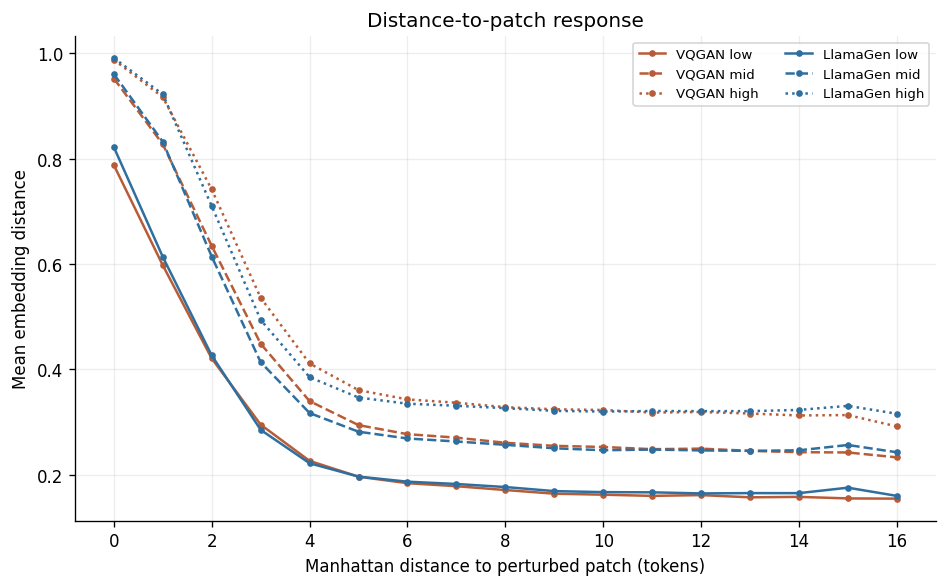

saved: /exp/vq-explore/notebooks/chapter6_outputs/figures/ch06_fig_distance_profile_flip.png


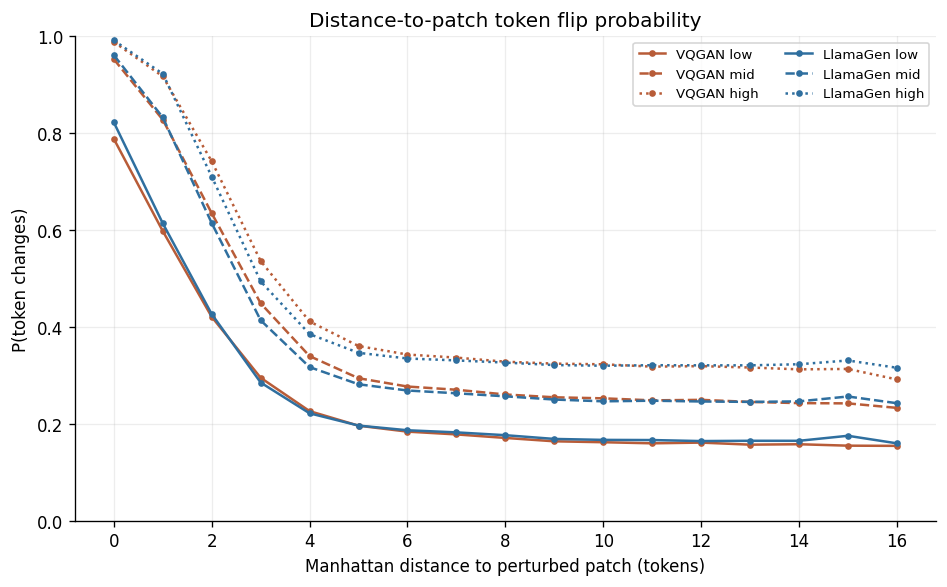

saved: /exp/vq-explore/notebooks/chapter6_outputs/figures/ch06_fig_distance_profile_embedding_log.png


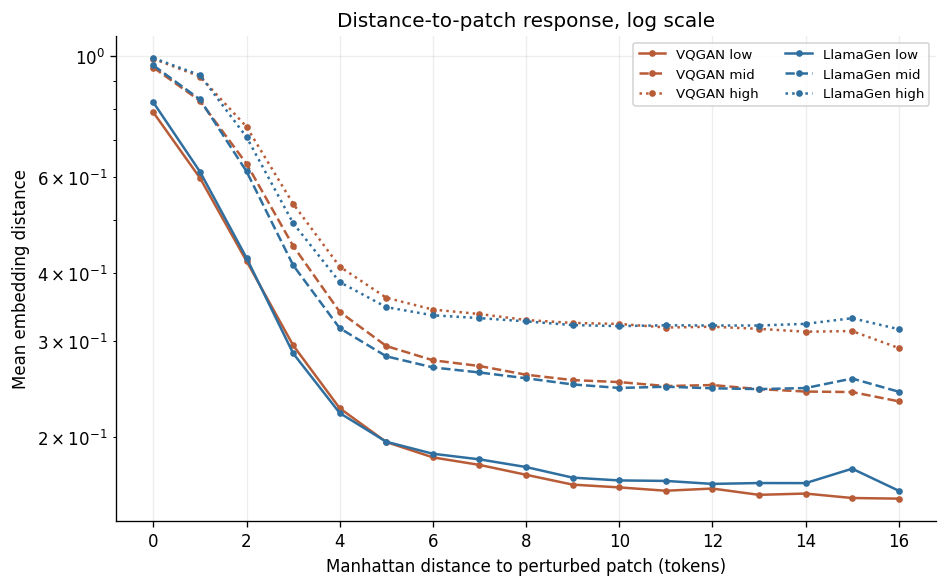

In [7]:
def compute_distance_profile_for_model(model: str, force: bool = False) -> pd.DataFrame:
    path = cache_path(f"ch06_distance_profile_{model}.csv")
    if not force and path.exists():
        print(f"loading cached distance profile for {model}")
        return load_df_cache(path)

    df_model = records_by_model[model]
    codebook = runs[model]["codebook"]
    inside_mask, _, _, grid_hw = build_inside_mask(df_model)
    dist_map = build_distance_map(df_model, grid_hw)
    max_d = int(dist_map.max())
    clean_ids = np.asarray(df_model["indices_clean"].to_list(), dtype=np.int32)

    rows = []
    for level, index_key, _, _ in LEVELS:
        noisy_ids = np.asarray(df_model[index_key].to_list(), dtype=np.int32)
        sum_dist = np.zeros(max_d + 1, dtype=np.float64)
        sum_flip = np.zeros(max_d + 1, dtype=np.float64)
        count = np.zeros(max_d + 1, dtype=np.int64)

        chunk_iter = tqdm(range(0, len(df_model), CFG.torch_chunk_rows), desc=f"Distance profile {MODEL_LABELS[model]} {level}")
        for start in chunk_iter:
            end = min(start + CFG.torch_chunk_rows, len(df_model))
            delta = compute_delta_chunk(clean_ids[start:end], noisy_ids[start:end], codebook)
            flips = (clean_ids[start:end] != noisy_ids[start:end]).astype(np.float32)
            d = dist_map[start:end]
            sum_dist += np.bincount(d.ravel(), weights=delta.ravel(), minlength=max_d + 1)
            sum_flip += np.bincount(d.ravel(), weights=flips.ravel(), minlength=max_d + 1)
            count += np.bincount(d.ravel(), minlength=max_d + 1)

        sigma = float(df_model["noise_std"].iloc[0][LEVEL_ORDER.index(level)])
        for d_value in range(max_d + 1):
            n = int(count[d_value])
            rows.append({
                "model": model,
                "level": level,
                "sigma": sigma,
                "distance": d_value,
                "count_tokens_total": n,
                "mean_embedding_distance": float(sum_dist[d_value] / n) if n else np.nan,
                "flip_probability": float(sum_flip[d_value] / n) if n else np.nan,
            })

    out_df = pd.DataFrame(rows)
    save_df_cache(out_df, path)
    return out_df


distance_profile_df = pd.concat(
    [compute_distance_profile_for_model(model, force=False) for model in MODEL_ORDER],
    ignore_index=True,
)
save_table(distance_profile_df, "ch06_table_distance_profile.csv")
display(distance_profile_df.head())

fig, ax = plt.subplots(figsize=(8, 5))
for model in MODEL_ORDER:
    for level in LEVEL_ORDER:
        sub = distance_profile_df[(distance_profile_df["model"] == model) & (distance_profile_df["level"] == level)]
        ax.plot(
            sub["distance"],
            sub["mean_embedding_distance"],
            marker="o",
            markersize=3,
            label=f"{MODEL_LABELS[model]} {level}",
            color=MODEL_COLORS[model],
            linestyle={"low": "-", "mid": "--", "high": ":"}[level],
        )
ax.set_title("Distance-to-patch response")
ax.set_xlabel("Manhattan distance to perturbed patch (tokens)")
ax.set_ylabel("Mean embedding distance")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
save_figure(fig, "ch06_fig_distance_profile_embedding.png")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for model in MODEL_ORDER:
    for level in LEVEL_ORDER:
        sub = distance_profile_df[(distance_profile_df["model"] == model) & (distance_profile_df["level"] == level)]
        ax.plot(
            sub["distance"],
            sub["flip_probability"],
            marker="o",
            markersize=3,
            label=f"{MODEL_LABELS[model]} {level}",
            color=MODEL_COLORS[model],
            linestyle={"low": "-", "mid": "--", "high": ":"}[level],
        )
ax.set_title("Distance-to-patch token flip probability")
ax.set_xlabel("Manhattan distance to perturbed patch (tokens)")
ax.set_ylabel("P(token changes)")
ax.set_ylim(0, 1)
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
save_figure(fig, "ch06_fig_distance_profile_flip.png")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for model in MODEL_ORDER:
    for level in LEVEL_ORDER:
        sub = distance_profile_df[(distance_profile_df["model"] == model) & (distance_profile_df["level"] == level)]
        y = np.clip(sub["mean_embedding_distance"].to_numpy(), 1e-8, None)
        ax.plot(sub["distance"], y, marker="o", markersize=3, label=f"{MODEL_LABELS[model]} {level}", color=MODEL_COLORS[model], linestyle={"low": "-", "mid": "--", "high": ":"}[level])
ax.set_yscale("log")
ax.set_title("Distance-to-patch response, log scale")
ax.set_xlabel("Manhattan distance to perturbed patch (tokens)")
ax.set_ylabel("Mean embedding distance")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
save_figure(fig, "ch06_fig_distance_profile_embedding_log.png")
plt.show()


## 10. Boundary and Far-Field Decomposition

Summarize the distance curves into interpretable bands:

- inside: `d = 0`
- boundary: `d = 1`
- near field: `1 <= d <= 2`
- far field: `d >= 6`

These bands are useful for the thesis prose because they separate immediate spillover from genuinely non-local response.

Planned outputs:

- `ch06_table_distance_band_summary.csv`
- `ch06_fig_near_far_response.png`

saved: /exp/vq-explore/notebooks/chapter6_outputs/data/ch06_table_distance_band_summary.csv


,model,level,sigma,band,count_tokens_total,mean_embedding_distance,flip_probability
0,VQGAN,low,0.10,inside_d0,3200000,0.787605,0.787605
1,VQGAN,low,0.10,boundary_d1,1422912,0.597390,0.597390
2,VQGAN,low,0.10,near_d1_2,2827320,0.509514,0.509514
3,VQGAN,low,0.10,far_ge_6,3062726,0.174103,0.174103
4,VQGAN,mid,0.25,inside_d0,3200000,0.952039,0.952039
5,VQGAN,mid,0.25,boundary_d1,1422912,0.827157,0.827157
6,VQGAN,mid,0.25,near_d1_2,2827320,0.731342,0.731342
7,VQGAN,mid,0.25,far_ge_6,3062726,0.265454,0.265454
8,VQGAN,high,0.50,inside_d0,3200000,0.987679,0.987679
9,VQGAN,high,0.50,boundary_d1,1422912,0.916595,0.916595


saved: /exp/vq-explore/notebooks/chapter6_outputs/figures/ch06_fig_near_far_response.png


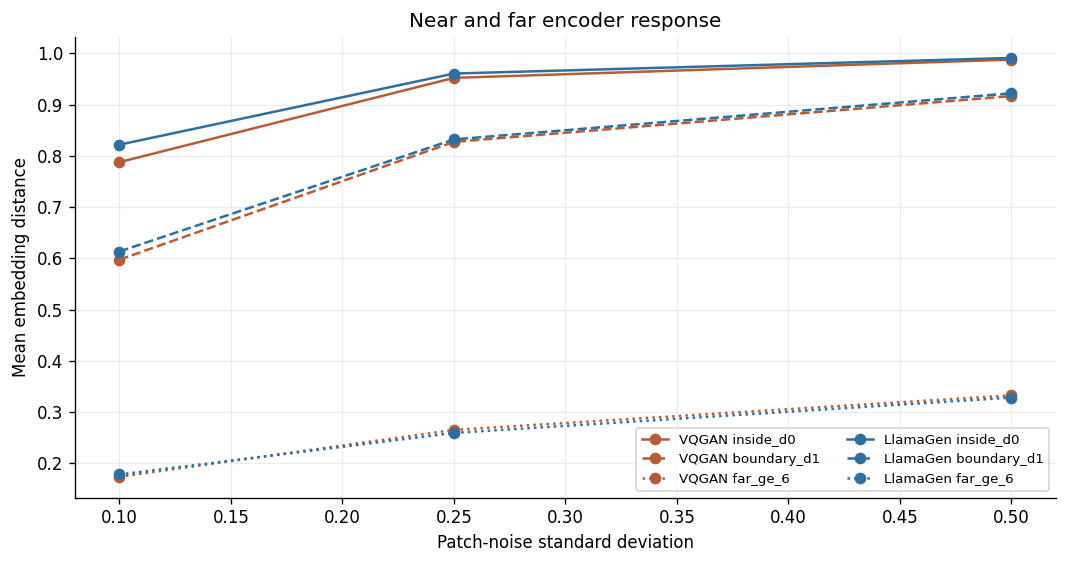

In [8]:
def summarize_distance_bands(profile_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (model, level), group in profile_df.groupby(["model", "level"], sort=False):
        sigma = float(group["sigma"].iloc[0])
        bands = {
            "inside_d0": group["distance"] == 0,
            "boundary_d1": group["distance"] == 1,
            f"near_d1_{CFG.d_near}": group["distance"].between(1, CFG.d_near),
            f"far_ge_{CFG.d_far}": group["distance"] >= CFG.d_far,
        }
        for band, mask in bands.items():
            sub = group[mask]
            weights = sub["count_tokens_total"].to_numpy(dtype=np.float64)
            weight_sum = weights.sum()
            rows.append({
                "model": MODEL_LABELS[model],
                "level": level,
                "sigma": sigma,
                "band": band,
                "count_tokens_total": int(weight_sum),
                "mean_embedding_distance": float(np.average(sub["mean_embedding_distance"], weights=weights)) if weight_sum else np.nan,
                "flip_probability": float(np.average(sub["flip_probability"], weights=weights)) if weight_sum else np.nan,
            })
    return pd.DataFrame(rows)


distance_band_summary = summarize_distance_bands(distance_profile_df)
save_table(distance_band_summary, "ch06_table_distance_band_summary.csv")
display(distance_band_summary)

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_df = distance_band_summary[distance_band_summary["band"].isin(["inside_d0", "boundary_d1", f"far_ge_{CFG.d_far}"])]
for model in MODEL_ORDER:
    label = MODEL_LABELS[model]
    for band, linestyle in [("inside_d0", "-"), ("boundary_d1", "--"), (f"far_ge_{CFG.d_far}", ":")]:
        sub = plot_df[(plot_df["model"] == label) & (plot_df["band"] == band)].sort_values("sigma")
        ax.plot(sub["sigma"], sub["mean_embedding_distance"], marker="o", color=MODEL_COLORS[model], linestyle=linestyle, label=f"{label} {band}")
ax.set_title("Near and far encoder response")
ax.set_xlabel("Patch-noise standard deviation")
ax.set_ylabel("Mean embedding distance")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
save_figure(fig, "ch06_fig_near_far_response.png")
plt.show()


## 11. Outside Leakage Concentration

The old updated notebook raised an important question: when outside leakage exists, is it concentrated in a few outside-token hotspots or diffuse across the image?

For outside-token distances `x`, compute top-5% mass:

$$\mathrm{top5\ mass}=\frac{\sum_{k\in\mathrm{Top\ 5\%}(x)}x_k}{\sum_k x_k}.$$

Planned outputs:

- `ch06_table_outside_concentration_summary.csv`
- `ch06_fig_outside_concentration_boxplot.png`
- `ch06_fig_outside_concentration_vs_leakage.png`

Outside concentration VQGAN low:   0%|          | 0/49 [00:00<?, ?it/s]

Outside concentration VQGAN mid:   0%|          | 0/49 [00:00<?, ?it/s]

Outside concentration VQGAN high:   0%|          | 0/49 [00:00<?, ?it/s]

cached: /exp/vq-explore/notebooks/chapter6_outputs/cache/ch06_outside_concentration_vqgan.csv


Outside concentration LlamaGen low:   0%|          | 0/49 [00:00<?, ?it/s]

Outside concentration LlamaGen mid:   0%|          | 0/49 [00:00<?, ?it/s]

Outside concentration LlamaGen high:   0%|          | 0/49 [00:00<?, ?it/s]

cached: /exp/vq-explore/notebooks/chapter6_outputs/cache/ch06_outside_concentration_llamagen.csv
saved: /exp/vq-explore/notebooks/chapter6_outputs/data/ch06_outside_concentration_rows.csv
saved: /exp/vq-explore/notebooks/chapter6_outputs/data/ch06_table_outside_concentration_summary.csv


,model,level,sigma,outside_mean_mean,outside_mean_std,outside_mean_median,outside_mean_q90,outside_mean_q99,outside_top5_mass_mean,outside_top5_mass_std,...,outside_max_mean,outside_max_std,outside_max_median,outside_max_q90,outside_max_q99,outside_nonzero_fraction_mean,outside_nonzero_fraction_std,outside_nonzero_fraction_median,outside_nonzero_fraction_q90,outside_nonzero_fraction_q99
0,VQGAN,low,0.10,0.299093,0.098267,0.291667,0.432292,0.541667,0.197958,0.083287,...,1.0,0.0,1.0,1.0,1.0,0.299093,0.098267,0.291667,0.432292,0.541667
1,VQGAN,mid,0.25,0.441234,0.084613,0.437500,0.552083,0.645833,0.122801,0.025974,...,1.0,0.0,1.0,1.0,1.0,0.441234,0.084613,0.437500,0.552083,0.645833
2,VQGAN,high,0.50,0.520889,0.079462,0.520833,0.625000,0.708333,0.102429,0.016394,...,1.0,0.0,1.0,1.0,1.0,0.520889,0.079462,0.520833,0.625000,0.708333
3,LlamaGen,low,0.10,0.301759,0.101319,0.296875,0.437500,0.552083,0.197697,0.086333,...,1.0,0.0,1.0,1.0,1.0,0.301759,0.101319,0.296875,0.437500,0.552083
4,LlamaGen,mid,0.25,0.427771,0.082862,0.427083,0.536458,0.630208,0.126826,0.027594,...,1.0,0.0,1.0,1.0,1.0,0.427771,0.082862,0.427083,0.536458,0.630208
5,LlamaGen,high,0.50,0.504776,0.077052,0.500000,0.604167,0.692708,0.105698,0.016930,...,1.0,0.0,1.0,1.0,1.0,0.504776,0.077052,0.500000,0.604167,0.692708


saved: /exp/vq-explore/notebooks/chapter6_outputs/figures/ch06_fig_outside_concentration_boxplot.png


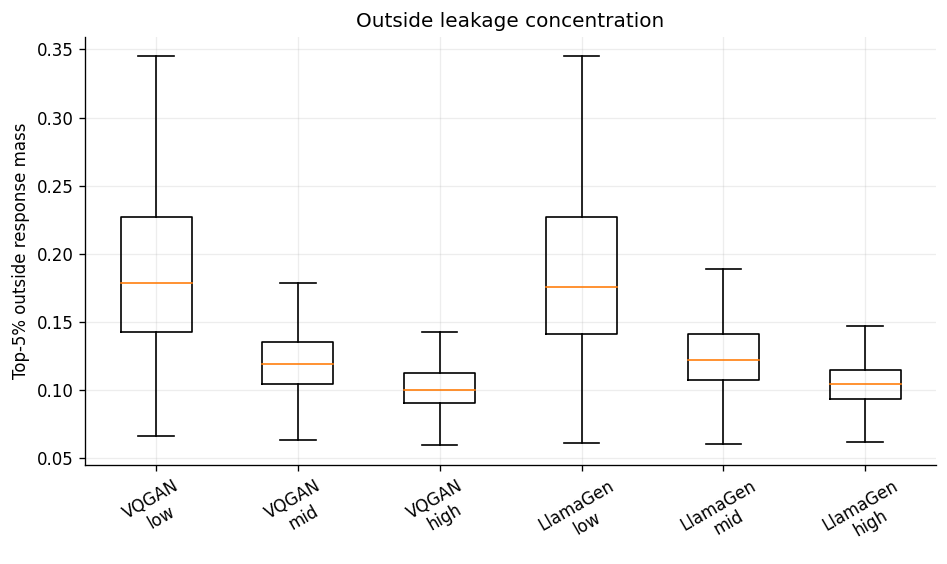

saved: /exp/vq-explore/notebooks/chapter6_outputs/figures/ch06_fig_outside_concentration_vs_leakage.png


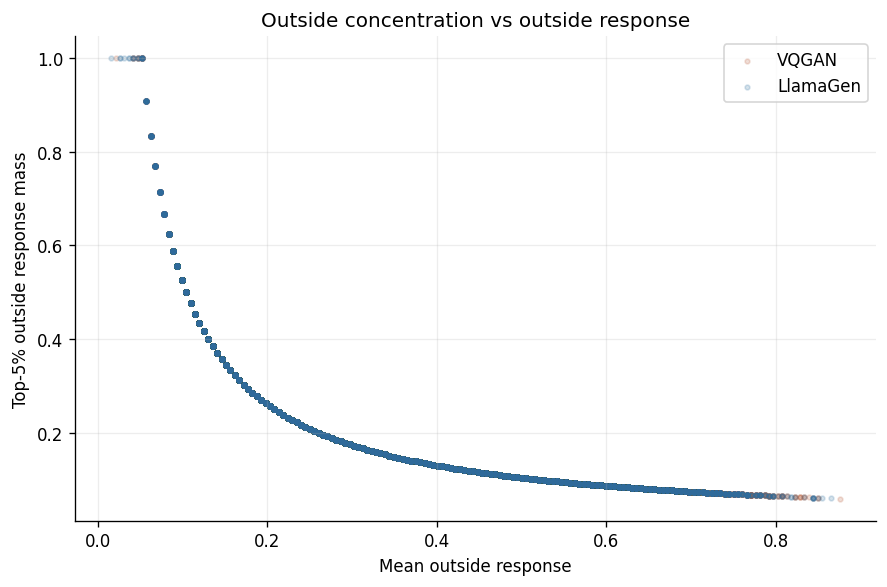

In [9]:
def topk_mass(values: np.ndarray, top_frac: float = CFG.top_frac, eps: float = 1e-12) -> float:
    values = np.asarray(values, dtype=np.float32)
    total = float(values.sum())
    if total <= eps:
        return np.nan
    k = max(1, int(math.ceil(top_frac * values.size)))
    top = np.partition(values, -k)[-k:]
    return float(top.sum() / total)


def compute_concentration_for_model(model: str, force: bool = False) -> pd.DataFrame:
    path = cache_path(f"ch06_outside_concentration_{model}.csv")
    if not force and path.exists():
        print(f"loading cached outside concentration for {model}")
        return load_df_cache(path)

    df_model = records_by_model[model]
    codebook = runs[model]["codebook"]
    inside_mask, _, _, _ = build_inside_mask(df_model)
    clean_ids = np.asarray(df_model["indices_clean"].to_list(), dtype=np.int32)

    rows = []
    for level, index_key, _, _ in LEVELS:
        noisy_ids = np.asarray(df_model[index_key].to_list(), dtype=np.int32)
        sigma = float(df_model["noise_std"].iloc[0][LEVEL_ORDER.index(level)])
        chunk_iter = tqdm(range(0, len(df_model), CFG.torch_chunk_rows), desc=f"Outside concentration {MODEL_LABELS[model]} {level}")
        for start in chunk_iter:
            end = min(start + CFG.torch_chunk_rows, len(df_model))
            delta = compute_delta_chunk(clean_ids[start:end], noisy_ids[start:end], codebook)
            for local_index, row_index in enumerate(range(start, end)):
                outside_values = delta[local_index][~inside_mask[row_index]]
                rows.append({
                    "model": model,
                    "image_id": df_model["image_id"].iloc[row_index],
                    "level": level,
                    "sigma": sigma,
                    "outside_mean": float(np.mean(outside_values)),
                    "outside_top5_mass": topk_mass(outside_values, CFG.top_frac),
                    "outside_max": float(np.max(outside_values)),
                    "outside_nonzero_fraction": float(np.mean(outside_values > 0)),
                })

    out_df = pd.DataFrame(rows)
    save_df_cache(out_df, path)
    return out_df


outside_concentration_df = pd.concat(
    [compute_concentration_for_model(model, force=False) for model in MODEL_ORDER],
    ignore_index=True,
)
save_table(outside_concentration_df, "ch06_outside_concentration_rows.csv")

concentration_summary_rows = []
for (model, level), group in outside_concentration_df.groupby(["model", "level"], sort=False):
    row = {"model": MODEL_LABELS[model], "level": level, "sigma": float(group["sigma"].iloc[0])}
    for col in ["outside_mean", "outside_top5_mass", "outside_max", "outside_nonzero_fraction"]:
        for key, value in summarize_array(group[col].to_numpy()).items():
            row[f"{col}_{key}"] = value
    concentration_summary_rows.append(row)

outside_concentration_summary = pd.DataFrame(concentration_summary_rows)
save_table(outside_concentration_summary, "ch06_table_outside_concentration_summary.csv")
display(outside_concentration_summary)

fig, ax = plt.subplots(figsize=(8, 4.8))
box_data = []
box_labels = []
for model in MODEL_ORDER:
    for level in LEVEL_ORDER:
        sub = outside_concentration_df[(outside_concentration_df["model"] == model) & (outside_concentration_df["level"] == level)]
        box_data.append(sub["outside_top5_mass"].dropna().to_numpy())
        box_labels.append(f"{MODEL_LABELS[model]}\n{level}")
ax.boxplot(box_data, labels=box_labels, showfliers=False)
ax.set_title("Outside leakage concentration")
ax.set_ylabel("Top-5% outside response mass")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
save_figure(fig, "ch06_fig_outside_concentration_boxplot.png")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 5))
for model in MODEL_ORDER:
    sub = outside_concentration_df[outside_concentration_df["model"] == model]
    ax.scatter(sub["outside_mean"], sub["outside_top5_mass"], s=8, alpha=0.20, color=MODEL_COLORS[model], label=MODEL_LABELS[model])
ax.set_title("Outside concentration vs outside response")
ax.set_xlabel("Mean outside response")
ax.set_ylabel("Top-5% outside response mass")
ax.legend()
fig.tight_layout()
save_figure(fig, "ch06_fig_outside_concentration_vs_leakage.png")
plt.show()


## 12. Masked Occlusion Variant

If `indices_masked` and the masked input/reconstruction images are present, treat black-mask occlusion as a secondary stress test. It should not replace the Gaussian patch-noise result, but it can help interpret whether the encoder response is specific to additive noise or also appears under stronger local occlusion.

Planned outputs if available:

- `ch06_table_masked_occlusion_summary.csv`
- `ch06_fig_masked_occlusion_qualitative.png`

In [10]:
def compute_masked_summary_for_model(model: str) -> pd.DataFrame | None:
    df_model = records_by_model[model]
    if "indices_masked" not in df_model.columns:
        return None
    codebook = runs[model]["codebook"]
    inside_mask, inside_count, outside_count, grid_hw = build_inside_mask(df_model)
    clean_ids = np.asarray(df_model["indices_clean"].to_list(), dtype=np.int32)
    masked_ids = np.asarray(df_model["indices_masked"].to_list(), dtype=np.int32)

    inside_values = np.empty(len(df_model), dtype=np.float32)
    outside_values = np.empty(len(df_model), dtype=np.float32)
    flip_inside_values = np.empty(len(df_model), dtype=np.float32)
    flip_outside_values = np.empty(len(df_model), dtype=np.float32)

    chunk_iter = tqdm(range(0, len(df_model), CFG.torch_chunk_rows), desc=f"Masked occlusion {MODEL_LABELS[model]}")
    for start in chunk_iter:
        end = min(start + CFG.torch_chunk_rows, len(df_model))
        delta = compute_delta_chunk(clean_ids[start:end], masked_ids[start:end], codebook)
        mask = inside_mask[start:end]
        outside_mask = ~mask
        inside_values[start:end] = (delta * mask).sum(axis=1) / inside_count[start:end]
        outside_values[start:end] = (delta * outside_mask).sum(axis=1) / outside_count[start:end]
        flips = (clean_ids[start:end] != masked_ids[start:end])
        flip_inside_values[start:end] = (flips * mask).sum(axis=1) / inside_count[start:end]
        flip_outside_values[start:end] = (flips * outside_mask).sum(axis=1) / outside_count[start:end]

    return pd.DataFrame({
        "model": model,
        "image_id": df_model["image_id"],
        "inside_response": inside_values,
        "outside_response": outside_values,
        "leakage_ratio": outside_values / (inside_values + 1e-8),
        "flip_inside": flip_inside_values,
        "flip_outside": flip_outside_values,
        "flip_leakage_ratio": flip_outside_values / (flip_inside_values + 1e-8),
    })


masked_frames = []
for model in MODEL_ORDER:
    masked_df = compute_masked_summary_for_model(model)
    if masked_df is not None:
        masked_frames.append(masked_df)

if masked_frames:
    masked_occlusion_df = pd.concat(masked_frames, ignore_index=True)
    save_table(masked_occlusion_df, "ch06_masked_occlusion_rows.csv")

    rows = []
    for model, group in masked_occlusion_df.groupby("model", sort=False):
        row = {"model": MODEL_LABELS[model], "level": "masked"}
        for col in ["inside_response", "outside_response", "leakage_ratio", "flip_inside", "flip_outside", "flip_leakage_ratio"]:
            for key, value in summarize_array(group[col].to_numpy()).items():
                row[f"{col}_{key}"] = value
        rows.append(row)
    masked_summary = pd.DataFrame(rows)
    save_table(masked_summary, "ch06_table_masked_occlusion_summary.csv")
    display(masked_summary)
else:
    print("No masked-occlusion fields found; skipping this optional section.")


Masked occlusion VQGAN:   0%|          | 0/49 [00:00<?, ?it/s]

Masked occlusion LlamaGen:   0%|          | 0/49 [00:00<?, ?it/s]

saved: /exp/vq-explore/notebooks/chapter6_outputs/data/ch06_masked_occlusion_rows.csv
saved: /exp/vq-explore/notebooks/chapter6_outputs/data/ch06_table_masked_occlusion_summary.csv


,model,level,inside_response_mean,inside_response_std,inside_response_median,inside_response_q90,inside_response_q99,outside_response_mean,outside_response_std,outside_response_median,...,flip_outside_mean,flip_outside_std,flip_outside_median,flip_outside_q90,flip_outside_q99,flip_leakage_ratio_mean,flip_leakage_ratio_std,flip_leakage_ratio_median,flip_leakage_ratio_q90,flip_leakage_ratio_q99
0,VQGAN,masked,0.997607,0.016551,1.0,1.0,1.0,0.56276,0.075843,0.562500,...,0.56276,0.075843,0.562500,0.661458,0.734375,0.563981,0.074991,0.562500,0.661458,0.734375
1,LlamaGen,masked,0.999504,0.010828,1.0,1.0,1.0,0.49458,0.066742,0.494792,...,0.49458,0.066742,0.494792,0.578125,0.656250,0.494775,0.066445,0.494792,0.578125,0.656250


## 13. Joint Chapter 6 Summary

Build the compact result tables that should be copied into the thesis chapter. This section should explicitly answer:

- How strong is the token response inside the perturbed patch?
- How much response leaks outside the patch?
- Does the outside response decay to zero with distance, or does it form a far-field plateau?
- Is outside leakage concentrated in hotspots or diffuse?
- Do VQGAN and LlamaGen differ in encoder locality?

Planned outputs:

- `ch06_table_joint_encoder_locality_summary.csv`
- `ch06_chapter_notes.md`

In [11]:
# Compact chapter summary tables.
joint_rows = []
for model in MODEL_ORDER:
    label = MODEL_LABELS[model]
    inside_sub = inside_outside_summary[inside_outside_summary["model"] == label]
    band_sub = distance_band_summary[distance_band_summary["model"] == label]
    concentration_sub = outside_concentration_summary[outside_concentration_summary["model"] == label]

    for level in LEVEL_ORDER:
        inside_row = inside_sub[inside_sub["level"] == level].iloc[0]
        far_row = band_sub[(band_sub["level"] == level) & (band_sub["band"] == f"far_ge_{CFG.d_far}")].iloc[0]
        boundary_row = band_sub[(band_sub["level"] == level) & (band_sub["band"] == "boundary_d1")].iloc[0]
        conc_row = concentration_sub[concentration_sub["level"] == level].iloc[0]
        joint_rows.append({
            "model": label,
            "level": level,
            "sigma": float(inside_row["sigma"]),
            "inside_response_mean": float(inside_row["inside_response_mean"]),
            "outside_response_mean": float(inside_row["outside_response_mean"]),
            "leakage_ratio_mean": float(inside_row["leakage_ratio_mean"]),
            "boundary_response_mean": float(boundary_row["mean_embedding_distance"]),
            "far_field_response_mean": float(far_row["mean_embedding_distance"]),
            "outside_top5_mass_mean": float(conc_row["outside_top5_mass_mean"]),
            "flip_inside_mean": float(inside_row["flip_inside_mean"]),
            "flip_outside_mean": float(inside_row["flip_outside_mean"]),
        })

joint_summary = pd.DataFrame(joint_rows)
save_table(joint_summary, "ch06_table_joint_encoder_locality_summary.csv")
display(joint_summary)

notes = [
    "# Chapter 6 Notes",
    "",
    "Use this file as a compact writing aid after running the notebook.",
    "",
]
for _, row in joint_summary.iterrows():
    notes.append(
        f"- {row['model']} {row['level']} (sigma={row['sigma']:.3g}): "
        f"inside={row['inside_response_mean']:.4f}, "
        f"outside={row['outside_response_mean']:.4f}, "
        f"leakage_ratio={row['leakage_ratio_mean']:.4f}, "
        f"far_field={row['far_field_response_mean']:.4f}, "
        f"outside_top5_mass={row['outside_top5_mass_mean']:.4f}."
    )

notes_path = DATA_DIR / "ch06_chapter_notes.md"
notes_path.write_text("\n".join(notes) + "\n")
print(f"saved: {notes_path}")


saved: /exp/vq-explore/notebooks/chapter6_outputs/data/ch06_table_joint_encoder_locality_summary.csv


,model,level,sigma,inside_response_mean,outside_response_mean,leakage_ratio_mean,boundary_response_mean,far_field_response_mean,outside_top5_mass_mean,flip_inside_mean,flip_outside_mean
0,VQGAN,low,0.10,0.787605,0.299093,0.374813,0.597390,0.174103,0.197958,0.787605,0.299093
1,VQGAN,mid,0.25,0.952039,0.441234,0.462345,0.827157,0.265454,0.122801,0.952039,0.441234
2,VQGAN,high,0.50,0.987679,0.520889,0.527170,0.916595,0.332807,0.102429,0.987679,0.520889
3,LlamaGen,low,0.10,0.821673,0.301759,0.361298,0.613379,0.178470,0.197697,0.821673,0.301759
4,LlamaGen,mid,0.25,0.960462,0.427771,0.444214,0.831950,0.259513,0.126826,0.960462,0.427771
5,LlamaGen,high,0.50,0.990918,0.504776,0.509183,0.922011,0.328436,0.105698,0.990918,0.504776


saved: /exp/vq-explore/notebooks/chapter6_outputs/data/ch06_chapter_notes.md
